# Examples for Geodesics on Toy Datasets

In [1]:
# libraries 
import torch 
import numpy as np 
from matplotlib import pyplot as plt 
import os
from functools import partial

In [2]:
!ls

anaconda3		  exrepo-receipts-extraction  plots
arrow_mask_rcnn		  extractions.zip	      riemannian-score-metrics
city-dev		  gvk-receipts-samples.zip    riem-score-metrics
classification_bert.png   ID-diff		      score-init
classification_gemma.png  __MACOSX		      score_metrics
DiffusionGeometry	  misc			      tmp
ex_repo			  mm-graph-parsing	      versions.txt
exrepo			  path-classifier


In [ ]:
%cd riem-score-metrics/

/home/moritz.burmester/riem-score-metrics


In [4]:
# local imports
from experiments_toy_datasets.manifolds.score_metrics import *
from experiments_toy_datasets.discrete_geodesics import *
from experiments_toy_datasets.graph_based_initialization import *
from experiments_toy_datasets.toy_datasets_utils import *
from experiments_toy_datasets.plotting import *
from experiments_toy_datasets.sample_pairs import *

(<Figure size 1300x650 with 2 Axes>,
 array([<AxesSubplot:title={'center':'1-sphere'}>,
        <AxesSubplot:title={'center':'s-curve'}>], dtype=object))

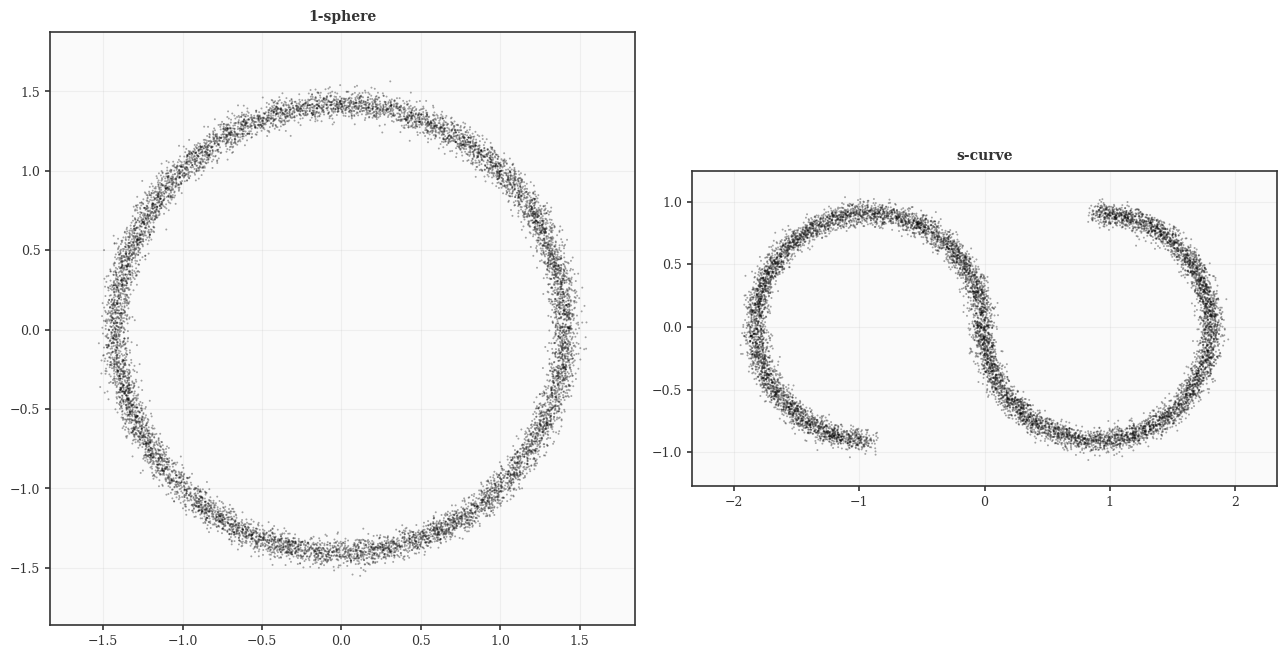

In [5]:
# plot the datasets 
datasets = ['1-sphere', 's-curve']
plot_grid(datasets, kind='data')

## Geodesics on S-Curve and Circle

In [9]:
data_dir = '/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/toy_data' 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Geodesics with INVP metric, with linear-init

In [16]:
n_points = 50
n_iter = 5000
lr = 5e-3
save_dir = '/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves'
os.makedirs(save_dir, exist_ok=True)

for ds_name in datasets:
    print(f'Dataset: {ds_name}')
    ## load the datasets 
    ds = load_dataset(ds_name, data_dir)
    X, meta = ds['X'], ds['meta']
    X = torch.tensor(X, dtype=torch.float32, device=device)
    idx = torch.randperm(X.shape[0])
    reference_points = X[idx[:2000]]


    # get the gmm parameters 
    means, sigma, weights = get_gmm_components(ds_name, meta, n_components=1500)
    deriv = AnalyticDeriv(means, sigma, weights).to(device=device) # provides score function, Hessian, logp, etc. 

    # define the metric, e.g. PER, SAI, AZE, INVP or ours (G_lam)
    # INVP, unnormalized
    manifold, _ = build_INVP(deriv=deriv, reference_points=reference_points, normalize=False)

    # optional: normalize the metric and cast it to be 1 on manifold, 1000 of manifold 
    #noisy_reference_points = torch.cat([reference_points] + [reference_points + 0.3*torch.randn_like(reference_points) for _ in range(2)], 0)
    #manifold, _ = build_INVP(deriv=deriv, reference_points=noisy_reference_points, target_min=1.0, target_max=1000, normalize=True)
    
    # sample pairs from the datasets (n = 1 here for example purposes)
    pairs = get_pairs(ds_name, meta, n_pairs = 1)

    # optimize geodesics (linear initialization for now)

    for pair_idx, (z0_np, z1_np) in enumerate(pairs):
            z0 = torch.tensor(z0_np, dtype=torch.float32, device=device)
            z1 = torch.tensor(z1_np, dtype=torch.float32, device=device)

            # lerp init
            t = torch.linspace(0, 1, n_points)[:, None].to(device)
            z_init = (1 - t) * z0[None, :] + t * z1[None, :]
            # run optimization loop 
            tag = f'{ds_name}/INVP/p{pair_idx}_linear'
            curve, history = discrete_geodesic_with_init(manifold, z0, z1, z_init, verbose_tag=tag)

            # save geodesics to disk for plotting purposes 
            fname = f'{ds_name}_INVP_p{pair_idx}_linear.pt'
            torch.save({
                'curve':         curve,
                'z0':            torch.tensor(z0_np),
                'z1':            torch.tensor(z1_np),
                'metric':        'INVP',
                'dataset':       ds_name,
                'pair_idx':      pair_idx,
            }, os.path.join(save_dir, fname))

Dataset: 1-sphere
1-sphere/INVP/p0_linear, ep=0, loss=12141942.0
1-sphere/INVP/p0_linear, ep=499, loss=667587.75
1-sphere/INVP/p0_linear, ep=999, loss=1389.810302734375
1-sphere/INVP/p0_linear, ep=1499, loss=322.95916748046875
1-sphere/INVP/p0_linear, ep=1999, loss=246.94284057617188
1-sphere/INVP/p0_linear, ep=2499, loss=218.9069061279297
1-sphere/INVP/p0_linear, ep=2999, loss=204.56163024902344
1-sphere/INVP/p0_linear, ep=3499, loss=196.04945373535156
1-sphere/INVP/p0_linear, ep=3999, loss=190.52748107910156
1-sphere/INVP/p0_linear, ep=4499, loss=186.69436645507812
1-sphere/INVP/p0_linear, ep=4999, loss=183.86734008789062
Dataset: s-curve
s-curve/INVP/p0_linear, ep=0, loss=7314166.0
s-curve/INVP/p0_linear, ep=499, loss=1163.890869140625
s-curve/INVP/p0_linear, ep=999, loss=349.83953857421875
s-curve/INVP/p0_linear, ep=1499, loss=208.69485473632812
s-curve/INVP/p0_linear, ep=1999, loss=152.98086547851562
s-curve/INVP/p0_linear, ep=2499, loss=123.97492218017578
s-curve/INVP/p0_linear, 

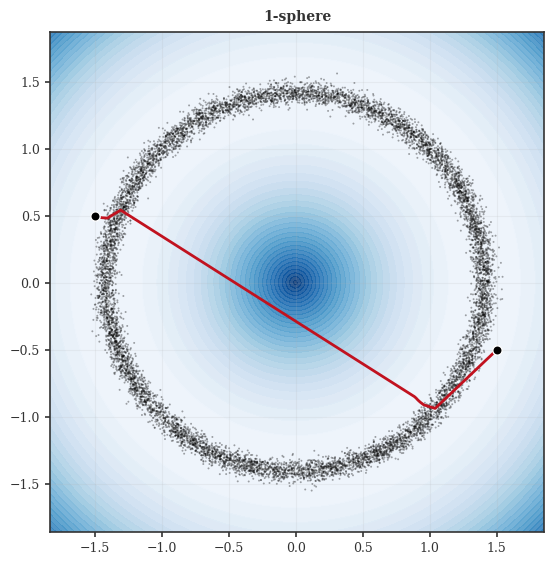

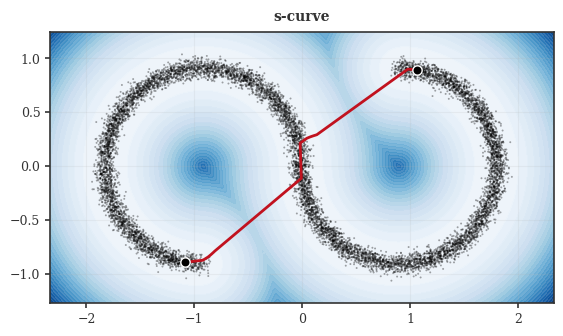

In [17]:
# plot geodesics
for ds_name in datasets: 
    for pair_idx, _ in enumerate(pairs):
        plot_curve(ds_name,
                f"/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves/{ds_name}_INVP_p{pair_idx}_linear.pt")



### Geodesics with INVP metric, with graph-init

In [ ]:
# Geodesics with graph-init 

n_points = 50
n_iter = 5000
lr = 5e-3
save_dir = '/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves'
os.makedirs(save_dir, exist_ok=True)

for ds_name in datasets:
    print(f'Dataset: {ds_name}')
    ## load the datasets 
    ds = load_dataset(ds_name, data_dir)
    X, meta = ds['X'], ds['meta']
    X = torch.tensor(X, dtype=torch.float32, device=device)
    idx = torch.randperm(X.shape[0])
    reference_points = X[idx[:2000]]

    # get the gmm parameters 
    means, sigma, weights = get_gmm_components(ds_name, meta, n_components=1500)
    deriv = AnalyticDeriv(means, sigma, weights).to(device=device) # provides score function, Hessian, logp, etc. 

    # define the metric, e.g. PER, SAI, AZE, INVP or ours (G_lam)
    # INVP, unnormalized
    manifold, _ = build_INVP(deriv=deriv, reference_points=reference_points, normalize=False)
    # optional: normalize metric between 1 and 1000
    #noisy_reference_points = torch.cat([reference_points] + [reference_points + 0.3*torch.randn_like(reference_points) for _ in range(2)], 0)
    #manifold, _ = build_INVP(deriv=deriv, reference_points=noisy_reference_points, target_min=1.0, target_max=1000, normalize=True)

    # sample pairs from the datasets
    pairs = get_pairs(ds_name, meta, n_pairs = 1)

    # optimize geodesics with graph init 
    for pair_idx, (z0_np, z1_np) in enumerate(pairs):
            z0 = torch.tensor(z0_np, dtype=torch.float32, device=device)
            z1 = torch.tensor(z1_np, dtype=torch.float32, device=device)

            # graph init
            data_np = X.detach().cpu().numpy()
            z_init = graph_init_curve(manifold, data_np, z0, z1, n_points,
                     k=15, N_edge=4, weight_floor=1e-8,
                     subsample=2000, seed=0, device='cpu')

            # run optimization loop 
            tag = f'{ds_name}/INVP/p{pair_idx}_graph'
            curve, history = discrete_geodesic_with_init(manifold, z0, z1, z_init, verbose_tag=tag)

            # save geodesics to disk for plotting purposes 
            fname = f'{ds_name}_INVP_p{pair_idx}_graph.pt'
            torch.save({
                'curve':         curve,
                'z0':            torch.tensor(z0_np),
                'z1':            torch.tensor(z1_np),
                'metric':        'INVP',
                'dataset':       ds_name,
                'pair_idx':      pair_idx,
            }, os.path.join(save_dir, fname))

Dataset: 1-sphere
1-sphere/INVP/p0_graph, ep=0, loss=385.9742431640625
1-sphere/INVP/p0_graph, ep=499, loss=15.937954902648926
1-sphere/INVP/p0_graph, ep=999, loss=15.941527366638184
1-sphere/INVP/p0_graph, ep=1499, loss=15.954648971557617
1-sphere/INVP/p0_graph, ep=1999, loss=15.964858055114746
1-sphere/INVP/p0_graph, ep=2499, loss=15.937296867370605
1-sphere/INVP/p0_graph, ep=2999, loss=15.937684059143066
1-sphere/INVP/p0_graph, ep=3499, loss=15.938529968261719
1-sphere/INVP/p0_graph, ep=3999, loss=15.93695068359375
1-sphere/INVP/p0_graph, ep=4499, loss=15.949071884155273
1-sphere/INVP/p0_graph, ep=4999, loss=15.947701454162598
Dataset: s-curve
s-curve/INVP/p0_graph, ep=0, loss=33.42350769042969
s-curve/INVP/p0_graph, ep=499, loss=32.512107849121094
s-curve/INVP/p0_graph, ep=999, loss=32.51210403442383
s-curve/INVP/p0_graph, ep=1499, loss=32.51214599609375
s-curve/INVP/p0_graph, ep=1999, loss=32.51220703125
s-curve/INVP/p0_graph, ep=2499, loss=32.512210845947266
s-curve/INVP/p0_graph

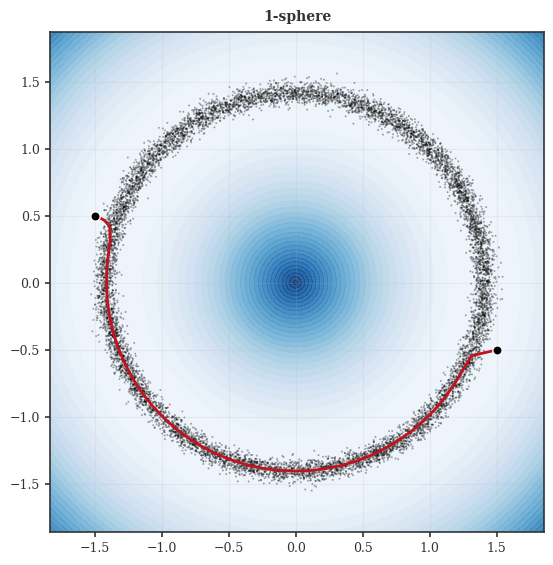

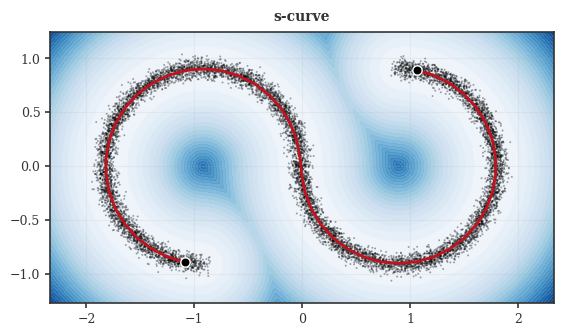

In [15]:
# plot geodesics
N_PAIRS = 1
for ds_name in datasets: 
    for pair_idx in range(N_PAIRS):
        plot_curve(ds_name,
                f"/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves/{ds_name}_INVP_p{pair_idx}_graph.pt")



### Geodesics with G metric across different lamda values, with graph-init
#### lam = 0 is the SAI metric, from Shinnosuke Saito and Takashi Matsubara: http://arxiv.org/abs/2510.05509.arXiv:2510.05509
#### lam > 0 is our proposed metric, and at lam=1, we recover the magnitude only metric

In [22]:
from experiments_toy_datasets.manifolds.score_metrics import _G, normalize_G

n_points = 50
n_iter = 5000
lr = 5e-3
save_dir = '/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves'
os.makedirs(save_dir, exist_ok=True)

for ds_name in datasets:
    print(f'Dataset: {ds_name}')
    ## load the datasets 
    ds = load_dataset(ds_name, data_dir)
    X, meta = ds['X'], ds['meta']
    X = torch.tensor(X, dtype=torch.float32, device=device)
    idx = torch.randperm(X.shape[0])
    reference_points = X[idx[:2000]]

    # get the gmm parameters 
    means, sigma, weights = get_gmm_components(ds_name, meta, n_components=1500)
    deriv = AnalyticDeriv(means, sigma, weights).to(device=device) # provides score function, Hessian, logp, etc. 

    # get normalization constants to put G terms on similar scale. 
    # has no effect on the curve at lam = 0 and lam = 1 since it's a global constant.
    noise_scale = 0.3
    n_noisy = 2 # 2x as many noisy points to normalize on 
    norm_stats = normalize_G(deriv, reference_points, noise_scale=noise_scale, n_noisy=n_noisy)
    print(f'  [G normalized] T_H={norm_stats["T_H"]:.3e}  T_s={norm_stats["T_s"]:.3e}'
            f'  postA={norm_stats["post_norm_mean_termA"]:.3f}'
            f'  postB={norm_stats["post_norm_mean_termB"]:.3f}')

    # lam = 0 -> SAI metric, lam = 1 --> magnitude only 
    lams = [0, 0.1, 0.5, 1]
    for lam in lams: 

        # build G metric 
        manifold = BaseManifold(partial(_G, deriv=deriv, lam=lam, normalize=True), name=f'G_{lam}')

        # sample pairs from the datasets
        pairs = get_pairs(ds_name, meta, n_pairs = 1)

        # optimize geodesics with graph init 
        for pair_idx, (z0_np, z1_np) in enumerate(pairs):
                z0 = torch.tensor(z0_np, dtype=torch.float32, device=device)
                z1 = torch.tensor(z1_np, dtype=torch.float32, device=device)

                # graph init
                data_np = X.detach().cpu().numpy()
                z_init = graph_init_curve(manifold, data_np, z0, z1, n_points,
                        k=15, N_edge=4, weight_floor=1e-8,
                        subsample=2000, seed=0, device='cpu')

                # run optimization loop 
                tag = f'{ds_name}/G_{lam}/p{pair_idx}'
                curve, history = discrete_geodesic_with_init(manifold, z0, z1, z_init, verbose_tag=tag)

                # save geodesics to disk for plotting purposes 
                fname = f'{ds_name}_G_{lam}_p{pair_idx}_graph.pt'
                torch.save({
                    'curve':         curve,
                    'z0':            torch.tensor(z0_np),
                    'z1':            torch.tensor(z1_np),
                    'metric':        f'G_{lam}',
                    'dataset':       ds_name,
                    'pair_idx':      pair_idx,
                }, os.path.join(save_dir, fname))

Dataset: 1-sphere
  [G normalized] T_H=1.618e+05  T_s=1.887e+04  postA=1.000  postB=1.000
1-sphere/G_0/p0, ep=0, loss=0.8209947347640991
1-sphere/G_0/p0, ep=499, loss=0.16049645841121674
1-sphere/G_0/p0, ep=999, loss=0.1512952744960785
1-sphere/G_0/p0, ep=1499, loss=0.14500588178634644
1-sphere/G_0/p0, ep=1999, loss=0.1416061818599701
1-sphere/G_0/p0, ep=2499, loss=0.13993102312088013
1-sphere/G_0/p0, ep=2999, loss=0.13783462345600128
1-sphere/G_0/p0, ep=3499, loss=0.12607336044311523
1-sphere/G_0/p0, ep=3999, loss=0.12511035799980164
1-sphere/G_0/p0, ep=4499, loss=0.12511944770812988
1-sphere/G_0/p0, ep=4999, loss=0.12479303777217865
1-sphere/G_0.1/p0, ep=0, loss=0.7819422483444214
1-sphere/G_0.1/p0, ep=499, loss=0.1488107442855835
1-sphere/G_0.1/p0, ep=999, loss=0.1259549856185913
1-sphere/G_0.1/p0, ep=1499, loss=0.11725591123104095
1-sphere/G_0.1/p0, ep=1999, loss=0.11268609762191772
1-sphere/G_0.1/p0, ep=2499, loss=0.1104968786239624
1-sphere/G_0.1/p0, ep=2999, loss=0.1094534844160

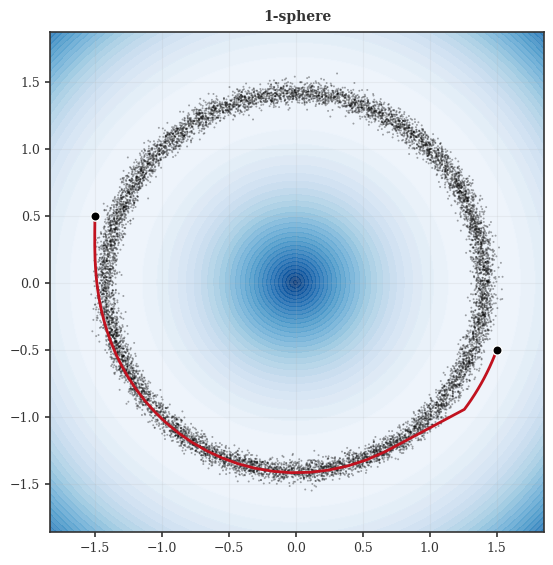

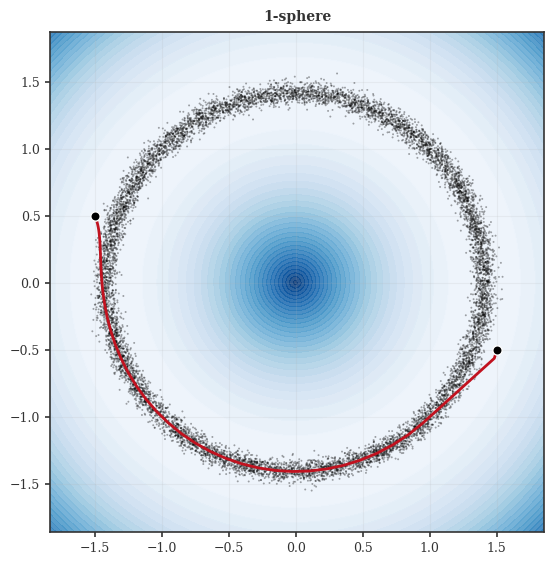

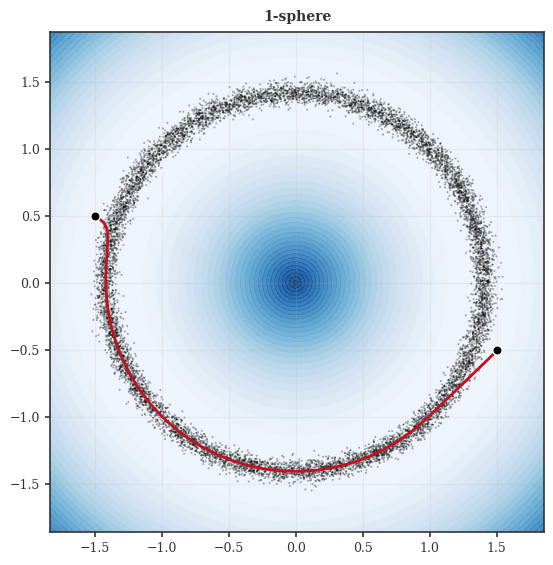

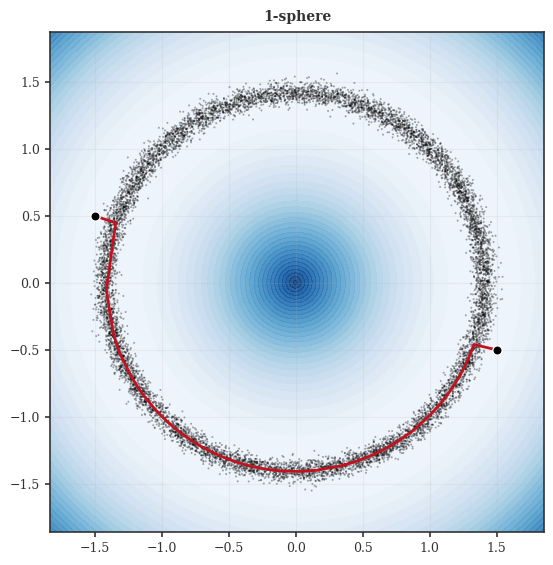

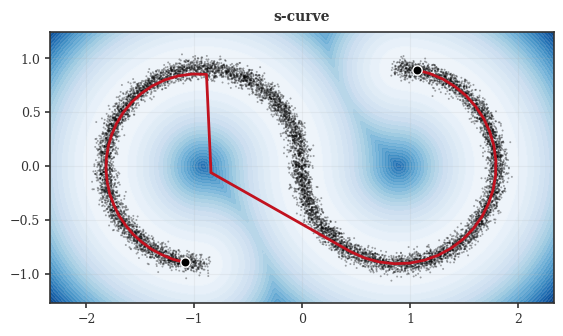

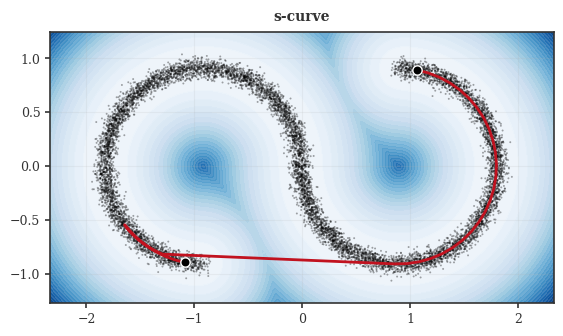

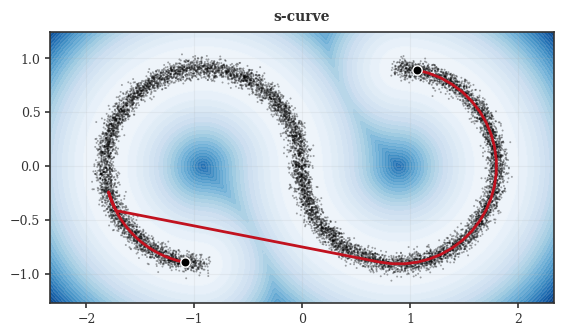

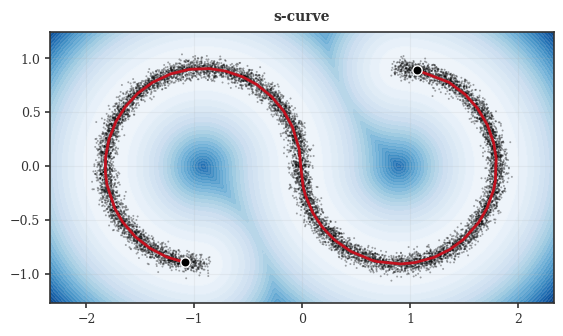

In [25]:
# plot geodesics
N_PAIRS = 1
for ds_name in datasets: 
    for pair_idx in range(N_PAIRS):
        for lam in lams: 
                plot_curve(ds_name,
                        f"/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves/{ds_name}_G_{lam}_p{pair_idx}_graph.pt")



### Normal Movement Metric (PER) and Tangential Movement Metric (AZE)
#### PER metric is from: Christian S. Perone: https://blog.christianperone.com/2024/11/the-geometry-of-data-part-ii/.
#### AZE metric: Simone Azeglio and Arianna Di Bernardo. http://arxiv.org/abs/2505.11128.arXiv:2505.11128.

In [27]:
from experiments_toy_datasets.manifolds.score_metrics import _AZE, _PER

manifolds = {
'AZE':      BaseManifold(partial(_AZE, deriv=deriv, lam=1.0), name='AZE'),
'PER':      BaseManifold(partial(_PER, deriv=deriv),          name='PER')
}

n_points = 50
n_iter = 2500
lr = 5e-3
save_dir = '/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves'
os.makedirs(save_dir, exist_ok=True)

for ds_name in datasets:
    print(f'Dataset: {ds_name}')
    ## load the datasets 
    ds = load_dataset(ds_name, data_dir)
    X, meta = ds['X'], ds['meta']
    X = torch.tensor(X, dtype=torch.float32, device=device)
    idx = torch.randperm(X.shape[0])
    reference_points = X[idx[:2000]]

    # get the gmm parameters 
    means, sigma, weights = get_gmm_components(ds_name, meta, n_components=1500)
    deriv = AnalyticDeriv(means, sigma, weights).to(device=device) # provides score function, Hessian, logp, etc. 

    # build AZE/PER metric 
    for manifold_name in manifolds.keys():
        
        manifold = manifolds[manifold_name]
        # sample pairs from the datasets
        pairs = get_pairs(ds_name, meta, n_pairs = 1)

        # optimize geodesics with graph init 
        for pair_idx, (z0_np, z1_np) in enumerate(pairs):
                z0 = torch.tensor(z0_np, dtype=torch.float32, device=device)
                z1 = torch.tensor(z1_np, dtype=torch.float32, device=device)

                # graph init
                data_np = X.detach().cpu().numpy()
                z_init = graph_init_curve(manifold, data_np, z0, z1, n_points,
                        k=15, N_edge=4, weight_floor=1e-8,
                        subsample=2000, seed=0, device='cpu')

                # run optimization loop 
                tag = f'{ds_name}/{manifold_name}/p{pair_idx}'
                curve, history = discrete_geodesic_with_init(manifold, z0, z1, z_init, verbose_tag=tag)

                # save geodesics to disk for plotting purposes 
                fname = f'{ds_name}_{manifold_name}_p{pair_idx}_graph.pt'
                torch.save({
                    'curve':         curve,
                    'z0':            torch.tensor(z0_np),
                    'z1':            torch.tensor(z1_np),
                    'metric':        f'G_{lam}',
                    'dataset':       ds_name,
                    'pair_idx':      pair_idx,
                }, os.path.join(save_dir, fname))

Dataset: 1-sphere
1-sphere/AZE/p0, ep=0, loss=2436.25048828125
1-sphere/AZE/p0, ep=499, loss=127.28839111328125
1-sphere/AZE/p0, ep=999, loss=111.99752044677734
1-sphere/AZE/p0, ep=1499, loss=102.6910629272461
1-sphere/AZE/p0, ep=1999, loss=95.92569732666016
1-sphere/AZE/p0, ep=2499, loss=90.79281616210938
1-sphere/AZE/p0, ep=2999, loss=88.57904815673828
1-sphere/AZE/p0, ep=3499, loss=83.1385726928711
1-sphere/AZE/p0, ep=3999, loss=80.1786117553711
1-sphere/AZE/p0, ep=4499, loss=79.83549499511719
1-sphere/AZE/p0, ep=4999, loss=76.42625427246094
1-sphere/PER/p0, ep=0, loss=9.377189636230469
1-sphere/PER/p0, ep=499, loss=0.059033073484897614
1-sphere/PER/p0, ep=999, loss=0.009189330972731113
1-sphere/PER/p0, ep=1499, loss=0.0014260680181905627
1-sphere/PER/p0, ep=1999, loss=0.0030959867872297764
1-sphere/PER/p0, ep=2499, loss=0.006097961217164993
1-sphere/PER/p0, ep=2999, loss=0.015069827437400818
1-sphere/PER/p0, ep=3499, loss=0.008379089646041393
1-sphere/PER/p0, ep=3999, loss=0.037198

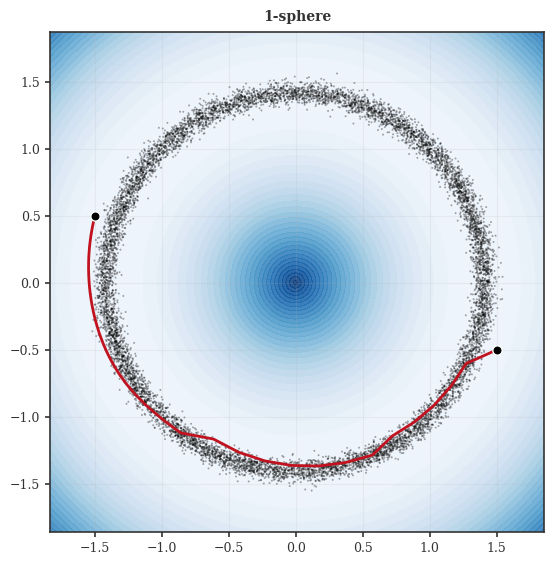

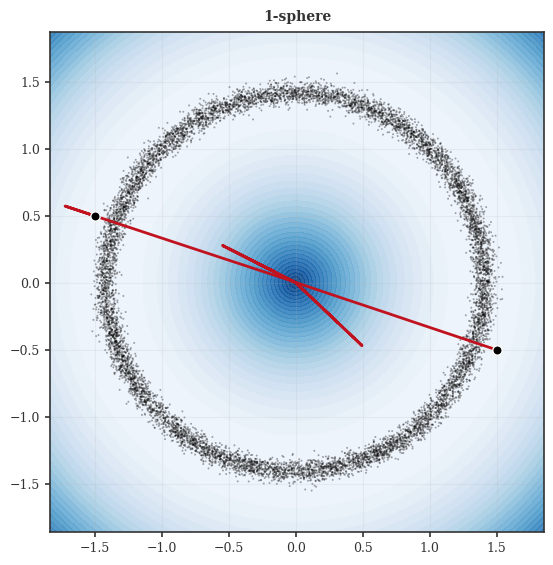

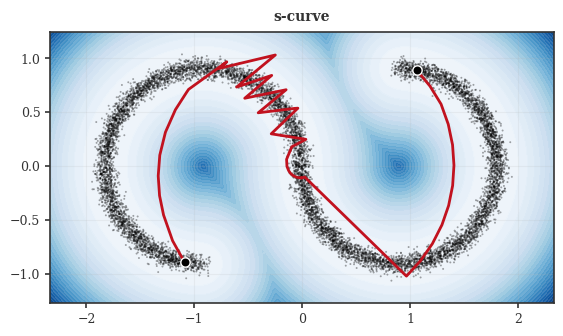

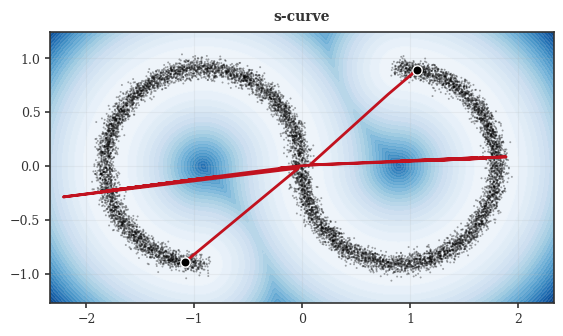

In [29]:
# plot geodesics
N_PAIRS = 1
for ds_name in datasets: 
    for pair_idx in range(N_PAIRS):
        for manifold_name in manifolds.keys(): 
                plot_curve(ds_name,
                        f"/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves/{ds_name}_{manifold_name}_p{pair_idx}_graph.pt")



### Learned Metrics, i.e., score function learned through a Neural Network 

In [5]:
import sys
sys.path.insert(0, '/home/moritz.burmester/riem-score-metrics/diffusion_model_dependencies')

from lightning_modules import BaseSdeGenerativeModel   
from models import fcn                                 
import lightning_data_modules.Toy2DDataset             
from lightning_modules.utils import create_lightning_module
from models.utils import get_score_fn
import losses, sde_lib, configs.default


2026-06-22 14:36:49.477073: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [6]:
from configs.default import get_default_configs
import ml_collections
from experiments_toy_datasets.model_utils import build_config
# change to path of downloaded checkpoint 
ckpt_path = "/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/model_logs/spiral/checkpoints/best/epoch=772--eval_loss_epoch=6.137.ckpt"
cfg = build_config(
    'spiral',
    sde='vesde', sigma_min=0.01, sigma_max=5.0,
    hidden_layers=4, hidden_nodes=128,
    epochs=1000, batch_size=128, lr=1e-3,
    ambient_dim=2, seed=12,
)
cfg.model.checkpoint_path = ckpt_path

In [10]:
# load the score function
pl = create_lightning_module(cfg)                 
pl = type(pl).load_from_checkpoint(ckpt_path)          
pl.config = cfg
pl.configure_sde(cfg)
pl = pl.to(device).eval()

score_fn = get_score_fn(pl.sde, pl.score_model,
                        conditional=False, train=False, continuous=True)

# set noise level, i.e. t = 0.2
t = 0.2 
# get hessian/jacobian matrix of score
from experiments_toy_datasets.manifolds.score_numeric import DiffusionDeriv
deriv = DiffusionDeriv(score_fn, t)

In [11]:
from experiments_toy_datasets.manifolds.score_metrics import _G, normalize_G

n_points = 50
n_iter = 5000
lr = 1e-3
save_dir = '/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves'
os.makedirs(save_dir, exist_ok=True)

ds_name = 'spiral'

print(f'Dataset: {ds_name}')
## load the datasets 
ds = load_dataset(ds_name, data_dir)
X, meta = ds['X'], ds['meta']
X = torch.tensor(X, dtype=torch.float32, device=device)
idx = torch.randperm(X.shape[0])
reference_points = X[idx[:2000]]

# get normalization constants to put G terms on similar scale. 
# has no effect on the curve at lam = 0 and lam = 1 since it's a global constant.
noise_scale = 0.35
n_noisy = 4 
norm_stats = normalize_G(deriv, reference_points, noise_scale=noise_scale, n_noisy=n_noisy)
print(f'  [G normalized] T_H={norm_stats["T_H"]:.3e}  T_s={norm_stats["T_s"]:.3e}'
        f'  postA={norm_stats["post_norm_mean_termA"]:.3f}'
        f'  postB={norm_stats["post_norm_mean_termB"]:.3f}')

# lam = 0 -> SAI metric, lam = 1 --> magnitude only 
lams = [1]
for lam in lams: 

        # build G metric 
        manifold = BaseManifold(partial(_G, deriv=deriv, lam=lam, normalize=True), name=f'G_{lam}')

        # sample pairs from the datasets
        pairs = get_pairs(ds_name, meta, n_pairs = 1)

        # optimize geodesics with graph init 
        for pair_idx, (z0_np, z1_np) in enumerate(pairs):
                z0 = torch.tensor(z0_np, dtype=torch.float32, device=device)
                z1 = torch.tensor(z1_np, dtype=torch.float32, device=device)

                # graph init
                data_np = X.detach().cpu().numpy()
                z_init = graph_init_curve(manifold, data_np, z0, z1, n_points,
                        k=15, N_edge=4, weight_floor=1e-8,
                        subsample=2000, seed=0, device='cuda') # change device 
                # run optimization loop 
                tag = f'{ds_name}/G_{lam}/p{pair_idx}_graph_learned'
                # use symmetric energy 
                curve, history = discrete_geodesic_with_init_symmetric(manifold, z0, z1, z_init, device=device, verbose_tag=tag) # change device 

                # save geodesics to disk for plotting purposes 
                fname = f'{ds_name}_G_{lam}_p{pair_idx}_graph_learned.pt'
                torch.save({
                        'curve':         curve,
                        'z0':            torch.tensor(z0_np),
                        'z1':            torch.tensor(z1_np),
                        'metric':        f'G_{lam}',
                        'dataset':       ds_name,
                        'pair_idx':      pair_idx,
                }, os.path.join(save_dir, fname))

Dataset: spiral
  [G normalized] T_H=3.442e+04  T_s=2.593e+03  postA=1.000  postB=1.000
spiral/G_1/p0_graph_learned, ep=0, loss=3.3299551010131836
spiral/G_1/p0_graph_learned, ep=499, loss=1.1965746879577637
spiral/G_1/p0_graph_learned, ep=999, loss=1.1765384674072266
spiral/G_1/p0_graph_learned, ep=1499, loss=1.134934425354004
spiral/G_1/p0_graph_learned, ep=1999, loss=1.128251314163208
spiral/G_1/p0_graph_learned, ep=2499, loss=1.1277891397476196
spiral/G_1/p0_graph_learned, ep=2999, loss=1.1274750232696533
spiral/G_1/p0_graph_learned, ep=3499, loss=1.1273095607757568
spiral/G_1/p0_graph_learned, ep=3999, loss=1.1272567510604858
spiral/G_1/p0_graph_learned, ep=4499, loss=1.1272400617599487
spiral/G_1/p0_graph_learned, ep=4999, loss=1.127241611480713


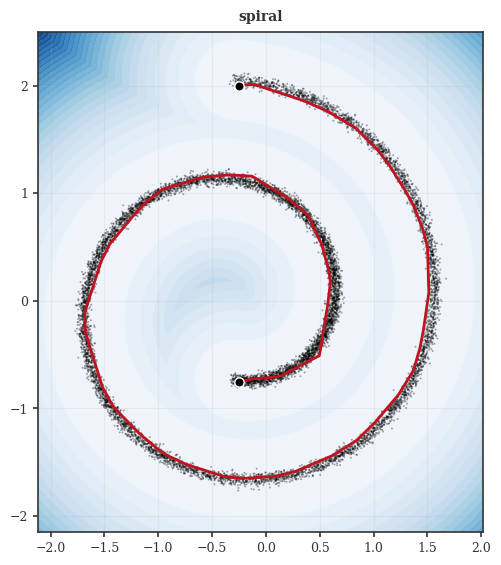

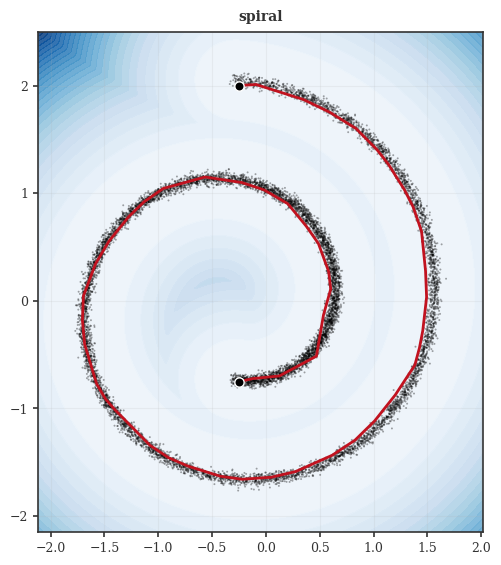

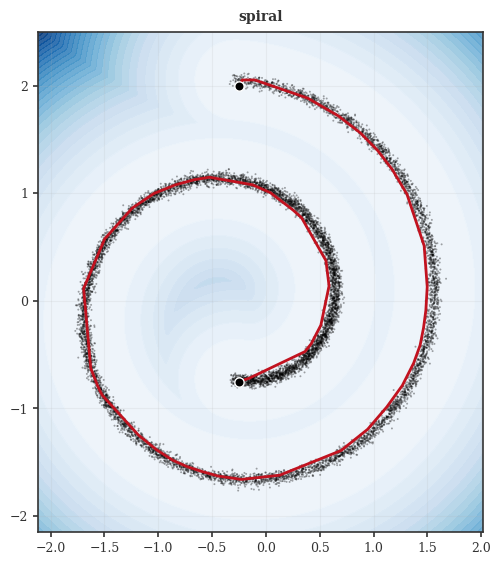

In [12]:
# plot geodesics
N_PAIRS = 1
lams = [0, 0.1, 1]
ds_name = 'spiral'
for pair_idx in range(N_PAIRS):
    for lam in lams: 
            plot_curve(ds_name,
                    f"/home/moritz.burmester/riem-score-metrics/experiments_toy_datasets/curves/{ds_name}_G_{lam}_p{pair_idx}_graph_learned.pt")
